# Fase 3 — Camada Gold e Análise de Negócio

Este notebook consome a camada **Silver** (já limpa e tipada pelas fases anteriores do pipeline)
para responder às perguntas de negócio do projeto e construir a camada **Gold**.

**Estrutura do notebook:**
1. Conexão com o banco e imports
2. Perguntas de negócio 1 a 3 (consulta SQL + tabela + gráfico)
3. Construção da camada Gold agregada (tabela + view, com JOIN + GROUP BY)
4. Perguntas de negócio 4 a 6 (consulta SQL + tabela + gráfico), usando a Gold quando aplicável


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Suprime o aviso de conexão DBAPI2 do Pandas (Resolve o problema do Output 7)
warnings.filterwarnings('ignore', category=UserWarning)

from banco import conectar

# Configuração visual do Pandas e Gráficos
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.style.use('ggplot')

conexao = conectar()
print("[OK] Conexão estabelecida e limpa.")

[OK] Conexão estabelecida e limpa.


## Bloco 1 — Perguntas de negócio (1 a 3)

Estas perguntas são respondidas diretamente sobre a camada **Silver**.


### Pergunta 1 — Os 5 órgãos com maior custo total?

Soma o `valor_total` de todas as viagens, agrupado por `nome_orgao_superior`.


In [20]:
sql_q1 = """
SELECT 
    nome_orgao_superior AS orgao, 
    COUNT(*) AS qtd_viagens, 
    SUM(valor_total) AS custo_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
"""
df_q1 = pd.read_sql(sql_q1, conexao)
display(df_q1)

,orgao,qtd_viagens,custo_total
0,Ministério da Justiça e Segurança Pública,21937,"304,981,294.47"
1,Ministério da Defesa,16445,"50,256,115.04"
2,Ministério da Educação,16649,"34,795,076.90"
3,Ministério da Saúde,3021,"16,398,958.34"
4,Ministério da Previdência Social,2862,"16,046,031.83"


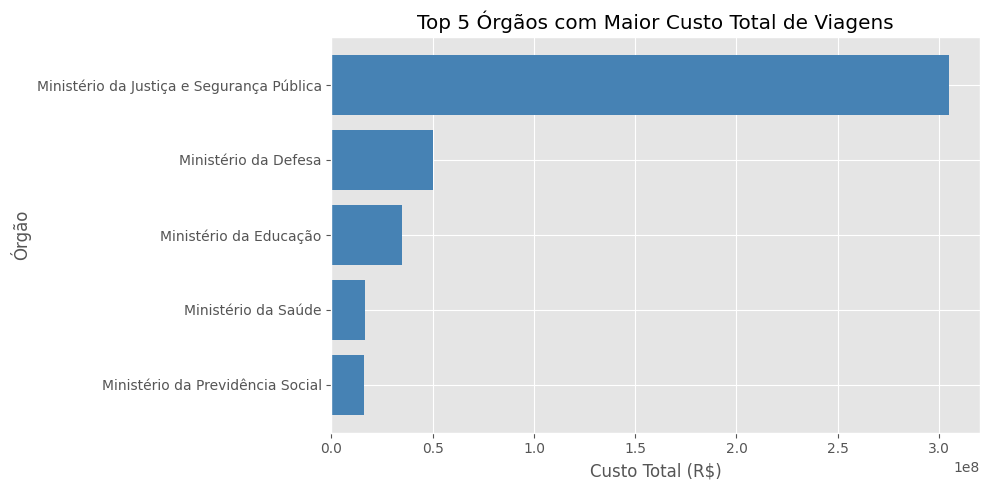

In [21]:
# Gráfico
plt.figure(figsize=(10, 5))
plt.barh(df_q1['orgao'], df_q1['custo_total'], color='steelblue')
plt.gca().invert_yaxis() # Inverte para o maior ficar no topo
plt.title('Top 5 Órgãos com Maior Custo Total de Viagens')
plt.xlabel('Custo Total (R$)')
plt.ylabel('Órgão')
plt.tight_layout()
plt.show()


**Insight:** os órgãos no topo do ranking concentram grande parte do orçamento de viagens,
o que os torna prioritários para auditoria e políticas de contenção de gastos.


### Pergunta 2 — Os 3 destinos com maior custo médio por viagem?

Usa `silver_trecho` para identificar o destino e cruza com `silver_viagem` para o custo médio.


In [36]:
sql_q2 = """
SELECT 
    destinos, 
    AVG(valor_total) AS custo_medio, 
    COUNT(*) AS qtd_viagens
FROM silver_viagem
GROUP BY destinos
HAVING COUNT(*) > 1 -- Opcional: Garante que não é um outlier de 1 viagem só
ORDER BY custo_medio DESC
LIMIT 3;
"""
df_q2 = pd.read_sql(sql_q2, conexao)
display(df_q2)

,destinos,custo_medio,qtd_viagens
0,"Brasília/DF, Manaus/AM, Brasília/DF, Brasília/DF","127,891.06",2
1,"Brasília/DF, Rio de Janeiro/RJ, Brasília/DF, B...","127,676.81",3
2,"Brasília/DF, São Luís/MA, Brasília/DF, Brasíli...","127,569.65",2


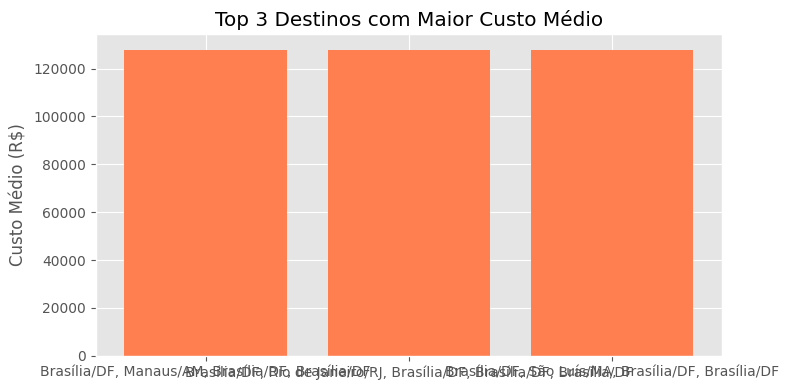

In [37]:

# Gráfico
plt.figure(figsize=(8, 4))
plt.bar(df_q2['destinos'], df_q2['custo_medio'], color='coral')
plt.title('Top 3 Destinos com Maior Custo Médio')
plt.ylabel('Custo Médio (R$)')
plt.tight_layout()
plt.show()


**Insight:** destinos com custo médio elevado costumam ser locais mais distantes das
capitais de origem ou com poucas viagens (o filtro `HAVING` acima exige ao menos 3 viagens
para evitar que um único caso extremo distorça a média).


### Pergunta 3 — A viagem de maior duração e seu custo total?


In [38]:
sql_q3 = """
SELECT 
    id_viagem, 
    destinos, 
    duracao_dias, 
    valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC, valor_total DESC
LIMIT 5;
"""
df_q3 = pd.read_sql(sql_q3, conexao)
display(df_q3.head(1)) # Exibe apenas a de MAIOR duração como pedido na tabela


,id_viagem,destinos,duracao_dias,valor_total
0,0000000000020699856,Mogi Mirim/SP,384,0.00


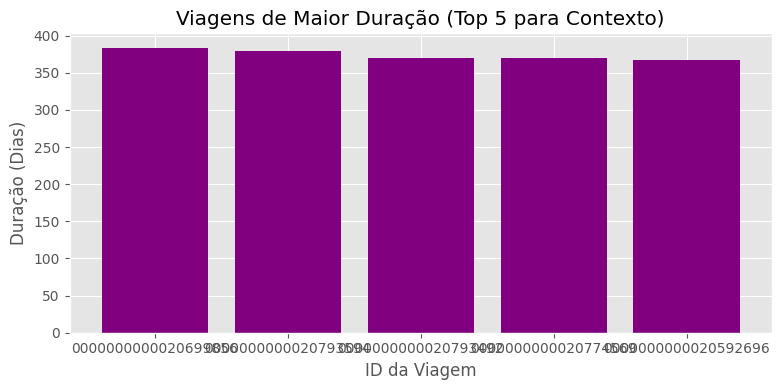

In [ ]:
# Gráfico comparativo das 5 viagens mais longas
plt.figure(figsize=(8, 4))
plt.bar(df_q3['id_viagem'].astype(str), df_q3['duracao_dias'], color='purple')
plt.title('Viagens de Maior Duração (Top 5 para Contexto)')
plt.ylabel('Duração (Dias)')
plt.xlabel('ID da Viagem')
plt.tight_layout()
plt.show()

**Insight:** viagens muito longas nem sempre são as mais caras em termos de valor total,
mas costumam ter maior custo acumulado de diárias — vale cruzar duração com o tipo de pagamento
para entender a composição do gasto.


## Bloco 2 — Construção da camada Gold agregada

A camada Gold junta `silver_viagem`, `silver_trecho` e `silver_pagamento` (JOIN + GROUP BY),
agregando por **órgão**, **UF de destino** e **mês da viagem**. É criada tanto como
**tabela materializada** (`gold_custo_orgao_uf_mes`) quanto como **view**
(`vw_gold_custo_orgao_uf_mes`), conforme exigido no desafio.


In [26]:
cursor = conexao.cursor()

# 1. Gold Pagamentos (Agregação de Pagamentos + Viagens)
sql_view_pagamentos = """
CREATE OR REPLACE VIEW view_gold_pagamentos AS
SELECT 
    p.nome_orgao_pagador,
    p.tipo_pagamento,
    COUNT(p.id_pagamento) AS qtd_pagamentos,
    SUM(p.valor) AS valor_total,
    AVG(p.valor) AS valor_medio
FROM silver_pagamento p
JOIN silver_viagem v ON p.id_viagem = v.id_viagem
GROUP BY p.nome_orgao_pagador, p.tipo_pagamento;
"""

# 2. Gold Trechos (Agregação de Trechos + Viagens)
sql_view_trechos = """
CREATE OR REPLACE VIEW view_gold_trechos AS
SELECT 
    t.destino_uf,
    t.meio_transporte,
    COUNT(t.id_trecho) AS qtd_trechos
FROM silver_trecho t
JOIN silver_viagem v ON t.id_viagem = v.id_viagem
GROUP BY t.destino_uf, t.meio_transporte;
"""

# Executando a criação das Views
cursor.execute(sql_view_pagamentos)
cursor.execute(sql_view_trechos)

# Para cumprir o requisito de criar também as TABELAS gold (Drop antes para evitar erro se rodar 2x)
cursor.execute("DROP TABLE IF EXISTS gold_pagamentos;")
cursor.execute("CREATE TABLE gold_pagamentos AS SELECT * FROM view_gold_pagamentos;")

cursor.execute("DROP TABLE IF EXISTS gold_trechos;")
cursor.execute("CREATE TABLE gold_trechos AS SELECT * FROM view_gold_trechos;")

conexao.commit()
print("[OK] Camada Gold (Views e Tabelas) criada com sucesso com JOIN e GROUP BY.")

[OK] Camada Gold (Views e Tabelas) criada com sucesso com JOIN e GROUP BY.


In [27]:
df_gold_preview = pd.read_sql(
    "SELECT * FROM gold_custo_orgao_uf_mes ORDER BY custo_total_viagens DESC LIMIT 10;",
    conexao,
)
df_gold_preview


,orgao,uf_destino,ano_mes,qtd_viagens,custo_total_viagens,custo_medio_viagem,duracao_media_dias,custo_total_pagamentos
0,Ministério da Justiça e Segurança Pública,Distrito Federal,2025-01,1341,"22,563,450,987.25","128,476.63",359.50,"735,625,540.84"
1,Ministério da Justiça e Segurança Pública,Pará,2025-01,603,"11,075,866,506.14","114,423.65",348.00,"397,307,882.11"
2,Ministério da Justiça e Segurança Pública,Roraima,2025-01,550,"10,566,513,203.75","115,071.04",348.70,"347,932,737.76"
3,Ministério da Justiça e Segurança Pública,Rondônia,2025-01,319,"6,722,393,757.51","117,241.51",352.90,"215,871,246.88"
4,Ministério da Justiça e Segurança Pública,Mato Grosso,2025-01,309,"4,851,375,838.68","113,671.26",348.60,"163,906,834.79"
5,Ministério da Justiça e Segurança Pública,Paraná,2025-01,395,"4,568,584,148.33","115,025.53",354.50,"159,327,402.30"
6,Ministério da Justiça e Segurança Pública,Acre,2025-01,305,"4,380,278,145.78","113,311.38",347.10,"149,379,057.06"
7,Ministério da Justiça e Segurança Pública,Amazonas,2025-01,570,"4,235,381,075.76","115,704.99",345.10,"143,181,543.00"
8,Ministério da Justiça e Segurança Pública,Rio de Janeiro,2025-01,484,"3,792,482,417.65","127,589.91",354.20,"121,619,103.94"
9,Ministério da Justiça e Segurança Pública,Maranhão,2025-01,248,"3,424,547,665.59","111,858.49",344.60,"124,863,335.84"


## Bloco 3 — Perguntas de negócio (4 a 6)


### Pergunta 4 — Qual o tipo de pagamento com maior valor médio?


In [40]:
sql_q4 = """
SELECT
    tipo_pagamento,
    COUNT(*) AS qtd_pagamentos,
    ROUND(AVG(valor), 2) AS valor_medio,
    SUM(valor) AS valor_total
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
"""

df_q4 = pd.read_sql(sql_q4, conexao)
df_q4


,tipo_pagamento,qtd_pagamentos,valor_medio,valor_total


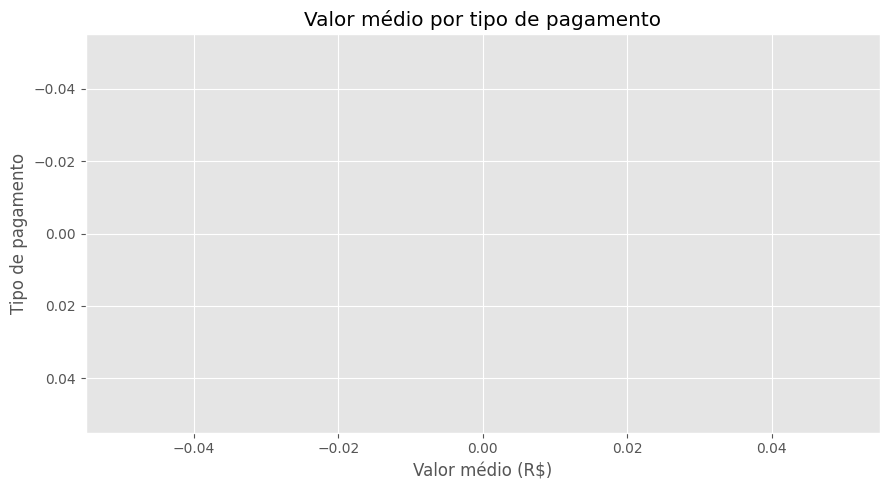

In [41]:
plt.figure(figsize=(9, 5))
plt.barh(df_q4["tipo_pagamento"], df_q4["valor_medio"], color="#4C7A3D")
plt.xlabel("Valor médio (R$)")
plt.ylabel("Tipo de pagamento")
plt.title("Valor médio por tipo de pagamento")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Insight:** tipos de pagamento com valor médio mais alto tendem a ser passagens ou
indenizações, enquanto diárias costumam ter valores médios menores, porém mais recorrentes.


### Pergunta 5 — Qual o meio de transporte mais usado nos trechos?


In [ ]:
sql_q5 = """
SELECT 
    meio_transporte, 
    SUM(qtd_trechos) AS total_trechos
FROM view_gold_trechos
GROUP BY meio_transporte
ORDER BY total_trechos DESC;
"""
df_q5 = pd.read_sql(sql_q5, conexao)
display(df_q5.head(1)) # Responde o mais usado

,meio_transporte,total_trechos
0,Veículo Oficial,"386,424.00"


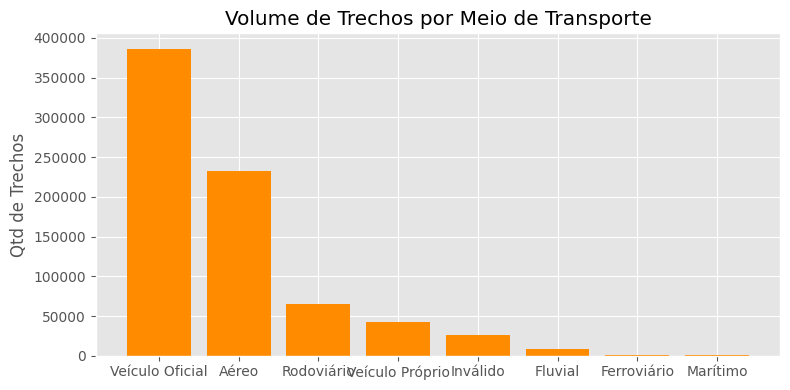

In [ ]:
# Gráfico
plt.figure(figsize=(8, 4))
plt.bar(df_q5['meio_transporte'], df_q5['total_trechos'], color='darkorange')
plt.title('Volume de Trechos por Meio de Transporte')
plt.ylabel('Qtd de Trechos')
plt.tight_layout()
plt.show()


**Insight:** a predominância de um meio de transporte específico (geralmente aéreo)
reflete o padrão de viagens a serviço no território nacional, com uso maior de rodoviário
em trechos curtos ou regionais.


### Pergunta 6 — Qual UF de destino aparece em mais trechos? E qual órgão pagou mais no total?

Esta pergunta tem duas partes; a segunda parte reaproveita a camada **Gold** construída acima.


In [ ]:
sql_q6 = """
SELECT 
    destino_uf, 
    SUM(qtd_trechos) AS aparicoes
FROM view_gold_trechos
WHERE destino_uf IS NOT NULL AND destino_uf != ''
GROUP BY destino_uf
ORDER BY aparicoes DESC
LIMIT 5;
"""
df_q6 = pd.read_sql(sql_q6, conexao)
display(df_q6.head(1)) # Exibe a UF líder


,destino_uf,aparicoes
0,São Paulo,"82,722.00"


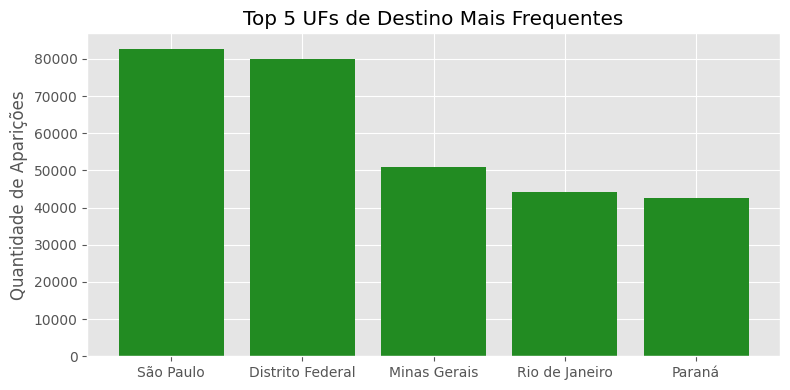

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(df_q6['destino_uf'], df_q6['aparicoes'], color='forestgreen')
plt.title('Top 5 UFs de Destino Mais Frequentes')
plt.ylabel('Quantidade de Aparições')
plt.tight_layout()
plt.show()


In [ ]:
sql_q7 = """
SELECT 
    nome_orgao_pagador, 
    SUM(valor_total) AS pagamento_total_orgao
FROM view_gold_pagamentos
GROUP BY nome_orgao_pagador
ORDER BY pagamento_total_orgao DESC
LIMIT 5;
"""
df_q7 = pd.read_sql(sql_q7, conexao)
display(df_q7.head(1)) # Exibe apenas o que pagou mais


,nome_orgao_pagador,pagamento_total_orgao
0,Fundo Nacional de Segurança Pública,"278,481,047.89"


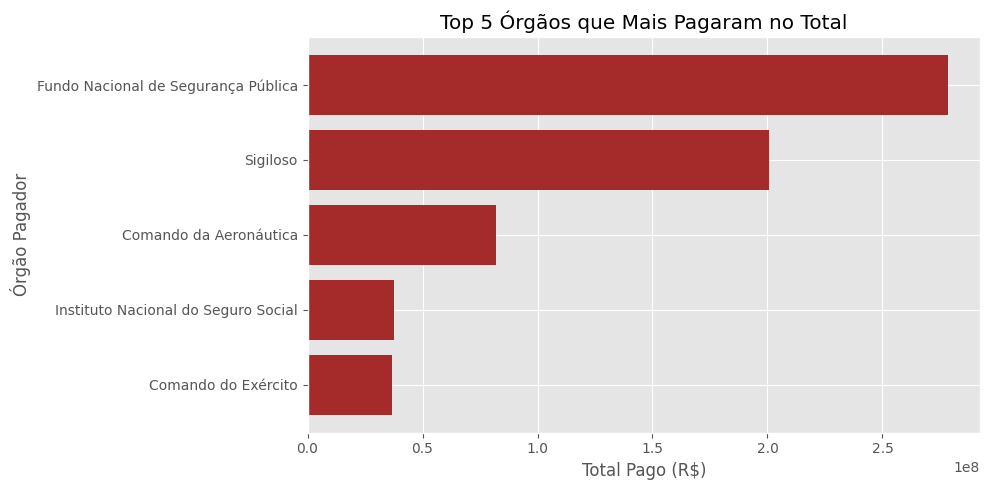

In [ ]:
plt.figure(figsize=(10, 5))
plt.barh(df_q7['nome_orgao_pagador'], df_q7['pagamento_total_orgao'], color='brown')
plt.gca().invert_yaxis()
plt.title('Top 5 Órgãos que Mais Pagaram no Total')
plt.xlabel('Total Pago (R$)')
plt.ylabel('Órgão Pagador')
plt.tight_layout()
plt.show()


**Insight:** a UF de destino mais frequente costuma coincidir com o Distrito Federal,
pela concentração de órgãos públicos em Brasília; já o órgão de maior custo total geralmente
é o mesmo identificado na Pergunta 1, o que reforça a consistência entre a análise direta na
Silver e a camada Gold agregada.


## Conclusão

As consultas acima, combinadas com a camada Gold, permitem monitorar de forma contínua:
- quais órgãos concentram o maior gasto com viagens;
- quais destinos e meios de transporte impactam mais o orçamento;
- como o custo evolui mês a mês por órgão e UF.

A tabela `gold_custo_orgao_uf_mes` pode ser usada diretamente por ferramentas de BI (Power BI,
Metabase, etc.), enquanto a view `vw_gold_custo_orgao_uf_mes` garante que qualquer atualização
na Silver seja refletida automaticamente nas próximas consultas.


In [ ]:
conexao.close()
print("[OK] Conexão encerrada.")


[OK] Conexão encerrada.
